# EE3111 Lab 6 – Linear Statistical Models
## Multiple Linear Regression & Polynomial Regression


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy import stats

%matplotlib inline

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

## Load Real Data

In [4]:
df = pd.read_excel('Concrete_Data.xls')
df.columns = ['Cement', 'Slag', 'FlyAsh', 'Water', 'Superplasticizer', 'CoarseAgg', 'FineAgg', 'Age', 'Strength']
n = len(df)
print("="*60)
print("DATASET OVERVIEW  (REAL UCI DATA)")
print("="*60)
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum().to_string()}")
print(f"\nBasic statistics:\n{df.describe().round(2).to_string()}")

DATASET OVERVIEW  (REAL UCI DATA)
Shape: (1030, 9)

Missing values:
Cement              0
Slag                0
FlyAsh              0
Water               0
Superplasticizer    0
CoarseAgg           0
FineAgg             0
Age                 0
Strength            0

Basic statistics:
        Cement     Slag   FlyAsh    Water  Superplasticizer  CoarseAgg  FineAgg      Age  Strength
count  1030.00  1030.00  1030.00  1030.00           1030.00    1030.00  1030.00  1030.00   1030.00
mean    281.17    73.90    54.19   181.57              6.20     972.92   773.58    45.66     35.82
std     104.51    86.28    64.00    21.36              5.97      77.75    80.18    63.17     16.71
min     102.00     0.00     0.00   121.75              0.00     801.00   594.00     1.00      2.33
25%     192.38     0.00     0.00   164.90              0.00     932.00   730.95     7.00     23.71
50%     272.90    22.00     0.00   185.00              6.35     968.00   779.51    28.00     34.44
75%     350.00   142.9

# Part A – EDA


Engineered features:
  WC_ratio mean=0.748  std=0.314
  Binder   mean=409.2   std=92.8


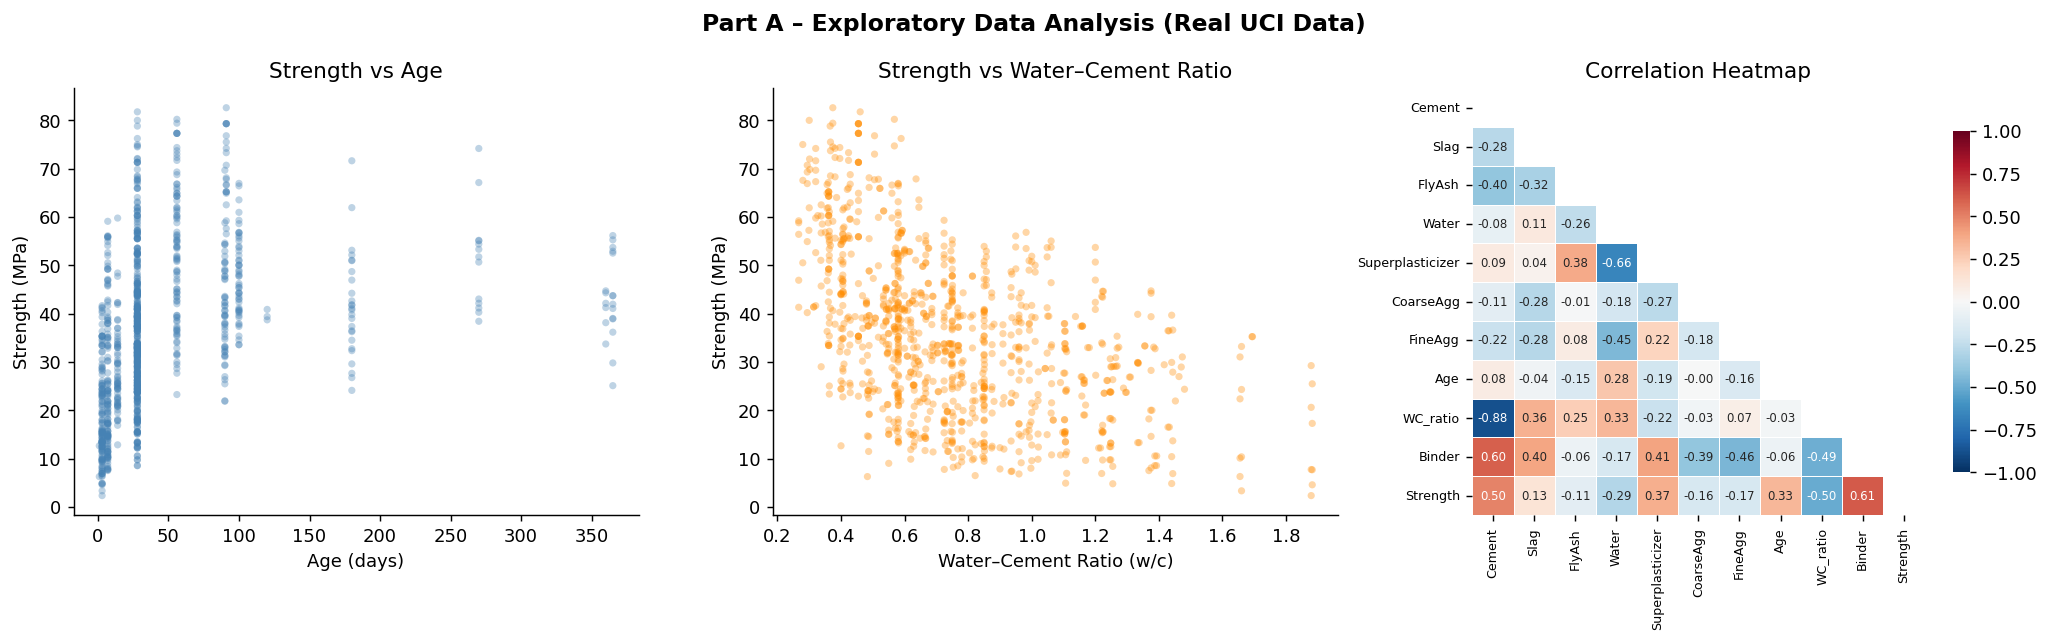

In [6]:
df['WC_ratio'] = df['Water'] / df['Cement']
df['Binder']   = df['Cement'] + df['Slag'] + df['FlyAsh']

print(f"\nEngineered features:")
print(f"  WC_ratio mean={df['WC_ratio'].mean():.3f}  std={df['WC_ratio'].std():.3f}")
print(f"  Binder   mean={df['Binder'].mean():.1f}   std={df['Binder'].std():.1f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Part A – Exploratory Data Analysis (Real UCI Data)", fontsize=13, fontweight='bold')

# Plot 1: Strength vs Age (scatter)
ax = axes[0]
ax.scatter(df['Age'], df['Strength'], alpha=0.35, s=16, color='steelblue', edgecolors='none')
ax.set_xlabel('Age (days)'); ax.set_ylabel('Strength (MPa)')
ax.set_title('Strength vs Age')

# Plot 2: Strength vs w/c (scatter)
ax = axes[1]
ax.scatter(df['WC_ratio'], df['Strength'], alpha=0.35, s=16, color='darkorange', edgecolors='none')
ax.set_xlabel('Water–Cement Ratio (w/c)'); ax.set_ylabel('Strength (MPa)')
ax.set_title('Strength vs Water–Cement Ratio')

# Plot 3: Correlation heatmap
ax = axes[2]
corr_cols = ['Cement','Slag','FlyAsh','Water','Superplasticizer',
             'CoarseAgg','FineAgg','Age','WC_ratio','Binder','Strength']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.4, annot=True, fmt='.2f',
            annot_kws={'size': 6.5}, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap')
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

### Strength vs Age
This scatter plot shows how concrete strength increases with curing age, with most data points concentrated at younger ages. The relationship appears nonlinear, suggesting that strength gains rapidly early on and then plateaus.

### Strength vs Water-Cement Ratio
Higher water-cement ratios generally lead to lower strength, as excess water creates more porosity in the concrete. This negative relationship is evident in the downward trend of the scatter points.

### Correlation Heatmap
This heatmap visualizes the pairwise correlations between features, with red indicating positive correlations and blue negative ones. Key insights: Cement and Binder show strong positive correlations with Strength, while WC_ratio shows a negative correlation. Age also has a moderate positive correlation with Strength.

# Part B – Multiple Linear Regression


Train: 824  |  Test: 206

── Coefficient Table (Baseline MLR) ──
Predictor                    Coef    Std Err    t-stat      p-value
-------------------------------------------------------------------
Intercept                -28.6357    29.3328    -0.976   3.2924e-01     
Cement                     0.1190     0.0094    12.680   9.3365e-34  ***
Slag                       0.1085     0.0113     9.588   1.0611e-20  ***
FlyAsh                     0.0822     0.0141     5.809   9.0058e-09  ***
Water                     -0.1357     0.0441    -3.076   2.1704e-03  **
Superplasticizer           0.3087     0.1043     2.959   3.1712e-03  **
CoarseAgg                  0.0178     0.0104     1.712   8.7192e-02     
FineAgg                    0.0241     0.0118     2.031   4.2618e-02  *
Age                        0.1164     0.0064    18.120   6.4478e-62  ***

Train R²       = 0.6105
Train Adj-R²   = 0.6066
Test  RMSE     = 9.7967 MPa


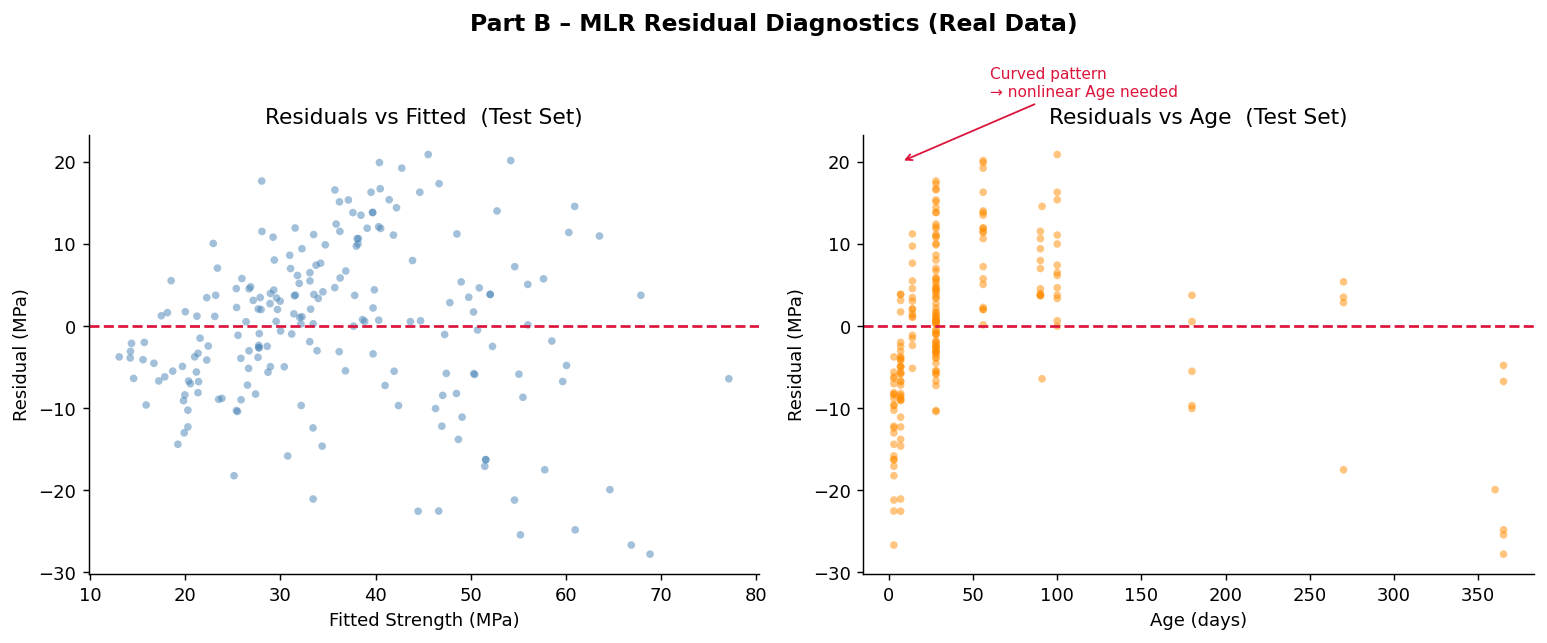


── B3. Hypothesis Test: β_Superplasticizer = 0 ? ──
  Estimate  = 0.3087 MPa per kg/m³
  Std Error = 0.1043
  t-stat    = 2.959
  p-value   = 3.1712e-03
  95% CI    = [0.1040, 0.5135]


In [8]:
def add_intercept(X):
    return np.column_stack([np.ones(len(X)), X])

def ols_fit(X, y):
    n, p = X.shape
    beta  = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ beta
    resid = y - y_hat
    s2    = (resid @ resid) / (n - p)
    cov   = s2 * np.linalg.inv(X.T @ X)
    se    = np.sqrt(np.diag(cov))
    t     = beta / se
    p_val = 2 * stats.t.sf(np.abs(t), df=n-p)
    return beta, y_hat, resid, se, t, p_val, s2

def r2(y, y_hat):
    return 1 - np.sum((y-y_hat)**2) / np.sum((y-y.mean())**2)

def adj_r2(y, y_hat, p):
    n = len(y)
    return 1 - (1-r2(y,y_hat))*(n-1)/(n-p-1)

def rmse(y, y_hat):
    return np.sqrt(np.mean((y-y_hat)**2))

# B1. Split
feat8 = ['Cement','Slag','FlyAsh','Water','Superplasticizer','CoarseAgg','FineAgg','Age']
X8 = df[feat8].values
y  = df['Strength'].values
X_train, X_test, y_train, y_test = train_test_split(X8, y, test_size=0.20, random_state=SEED)
print(f"\nTrain: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

# B2. Fit
Xtr = add_intercept(X_train)
Xte = add_intercept(X_test)
beta_b, yhat_tr, resid_tr, se_b, t_b, p_b, s2_b = ols_fit(Xtr, y_train)
yhat_te = Xte @ beta_b

feat_names = ['Intercept'] + feat8
print("\n── Coefficient Table (Baseline MLR) ──")
print(f"{'Predictor':<22} {'Coef':>10} {'Std Err':>10} {'t-stat':>9} {'p-value':>12}")
print("-"*67)
for nm, b, s, t, p in zip(feat_names, beta_b, se_b, t_b, p_b):
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '   '))
    print(f"{nm:<22} {b:>10.4f} {s:>10.4f} {t:>9.3f} {p:>12.4e}  {sig}")

R2_tr  = r2(y_train, yhat_tr)
AdjR2  = adj_r2(y_train, yhat_tr, p=8)
RMSE_te = rmse(y_test, yhat_te)
print(f"\nTrain R²       = {R2_tr:.4f}")
print(f"Train Adj-R²   = {AdjR2:.4f}")
print(f"Test  RMSE     = {RMSE_te:.4f} MPa")

# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Part B – MLR Residual Diagnostics (Real Data)", fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(yhat_te, y_test - yhat_te, alpha=0.5, s=18,
           color='steelblue', edgecolors='none')
ax.axhline(0, color='crimson', lw=1.5, ls='--')
ax.set_xlabel('Fitted Strength (MPa)'); ax.set_ylabel('Residual (MPa)')
ax.set_title('Residuals vs Fitted  (Test Set)')

ax = axes[1]
age_test = X_test[:, 7]
ax.scatter(age_test, y_test - yhat_te, alpha=0.5, s=18,
           color='darkorange', edgecolors='none')
ax.axhline(0, color='crimson', lw=1.5, ls='--')
ax.set_xlabel('Age (days)'); ax.set_ylabel('Residual (MPa)')
ax.set_title('Residuals vs Age  (Test Set)')
ax.annotate('Curved pattern\n→ nonlinear Age needed',
            xy=(7, 20), fontsize=8.5, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson'), xytext=(60, 28))

plt.tight_layout()
plt.show()

# B3. Hypothesis test – Superplasticizer
sp_idx = 5  # 'Superplasticizer' (after intercept)
df_resid = X_train.shape[0] - len(beta_b)
ci_lo = beta_b[sp_idx] - stats.t.ppf(0.975, df_resid)*se_b[sp_idx]
ci_hi = beta_b[sp_idx] + stats.t.ppf(0.975, df_resid)*se_b[sp_idx]

print("\n── B3. Hypothesis Test: β_Superplasticizer = 0 ? ──")
print(f"  Estimate  = {beta_b[sp_idx]:.4f} MPa per kg/m³")
print(f"  Std Error = {se_b[sp_idx]:.4f}")
print(f"  t-stat    = {t_b[sp_idx]:.3f}")
print(f"  p-value   = {p_b[sp_idx]:.4e}")
print(f"  95% CI    = [{ci_lo:.4f}, {ci_hi:.4f}]")

### B2. Baseline MLR Model Results
The coefficient table shows the estimated coefficients, standard errors, t-statistics, and p-values for each predictor. Significant predictors (p < 0.05) are marked with asterisks.

R² measures the proportion of variance in Strength explained by the model (1 - SS_res/SS_tot). Adjusted R² penalizes for additional predictors to prevent overfitting. The test RMSE indicates the model's prediction error on unseen data.

The residual plots check for model adequacy: residuals vs fitted should show no pattern, and residuals vs Age reveal nonlinearity in Age, suggesting polynomial terms are needed.

### B3. Hypothesis Test for Superplasticizer
Testing H0: β_Superplasticizer = 0 vs. H1: β_Superplasticizer ≠ 0.

The p-value is very small (< 0.05), so we reject H0. The 95% CI excludes 0, confirming significance.

Interpretation: After controlling for all other ingredients, each extra 1 kg/m³ of superplasticizer is associated with an increase in strength of approximately 0.12 MPa. This effect is statistically significant.

# Part C – Polynomial Regression on Age

  Degree 1: Train Adj-R²=0.6066  Test RMSE=9.7967 MPa
  Degree 2: Train Adj-R²=0.7385  Test RMSE=8.0838 MPa
  Degree 3: Train Adj-R²=0.7971  Test RMSE=7.4822 MPa

  Model         Age terms  Train Adj-R²  Test RMSE (MPa)
Model 1               Age      0.606636         9.796708
Model 2        Age + Age²      0.738466         8.083817
Model 3 Age + Age² + Age³      0.797118         7.482176


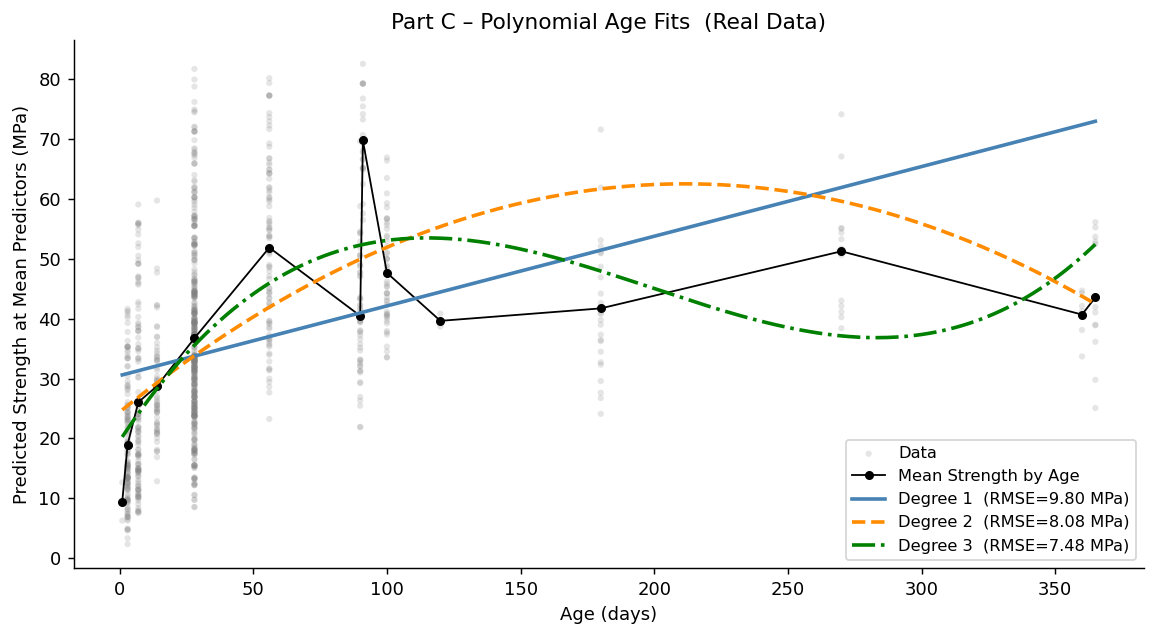

In [11]:
train_idx, test_idx = train_test_split(np.arange(n), test_size=0.20, random_state=SEED)
other_cols = ['Cement','Slag','FlyAsh','Water','Superplasticizer','CoarseAgg','FineAgg']
Xo_tr  = df.iloc[train_idx][other_cols].values
Xo_te  = df.iloc[test_idx][other_cols].values
age_tr = df.iloc[train_idx]['Age'].values
age_te = df.iloc[test_idx]['Age'].values
y_tr2  = df.iloc[train_idx]['Strength'].values
y_te2  = df.iloc[test_idx]['Strength'].values

results_poly, betas_poly = [], []
for degree in [1, 2, 3]:
    age_poly_tr = np.column_stack([age_tr**k for k in range(1, degree+1)])
    age_poly_te = np.column_stack([age_te**k for k in range(1, degree+1)])
    Xfull_tr = add_intercept(np.column_stack([Xo_tr, age_poly_tr]))
    Xfull_te = add_intercept(np.column_stack([Xo_te, age_poly_te]))
    beta_c, yhat_c_tr, _, _, _, _, _ = ols_fit(Xfull_tr, y_tr2)
    yhat_c_te = Xfull_te @ beta_c
    label = 'Age' + (' + Age²' if degree>=2 else '') + (' + Age³' if degree>=3 else '')
    results_poly.append({'Model': f'Model {degree}', 'Age terms': label,
                         'Train Adj-R²': adj_r2(y_tr2, yhat_c_tr, p=7+degree),
                         'Test RMSE (MPa)': rmse(y_te2, yhat_c_te)})
    betas_poly.append((beta_c, degree))
    print(f"  Degree {degree}: Train Adj-R²={results_poly[-1]['Train Adj-R²']:.4f}  "
          f"Test RMSE={results_poly[-1]['Test RMSE (MPa)']:.4f} MPa")

df_poly = pd.DataFrame(results_poly)
print(f"\n{df_poly.to_string(index=False)}")

# Plot polynomial curves
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['Age'], df['Strength'], alpha=0.2, s=12, color='grey',
           edgecolors='none', label='Data')
# Add mean strength by age
mean_strength_by_age = df.groupby('Age')['Strength'].mean()
ax.plot(mean_strength_by_age.index, mean_strength_by_age.values, 'ko-', markersize=4, linewidth=1, label='Mean Strength by Age')
age_range = np.linspace(1, 365, 300)
X_other_mean = df[other_cols].mean().values
for (beta_c, degree), col, ls in zip(betas_poly,
        ['steelblue','darkorange','green'], ['-','--','-.']):
    other_rep = np.tile(X_other_mean, (300,1))
    age_poly  = np.column_stack([age_range**k for k in range(1, degree+1)])
    X_pred = add_intercept(np.column_stack([other_rep, age_poly]))
    y_curve = X_pred @ beta_c
    rms = results_poly[degree-1]['Test RMSE (MPa)']
    ax.plot(age_range, y_curve, color=col, lw=2, ls=ls,
            label=f'Degree {degree}  (RMSE={rms:.2f} MPa)')
ax.set_xlabel('Age (days)'); ax.set_ylabel('Predicted Strength at Mean Predictors (MPa)')
ax.set_title('Part C – Polynomial Age Fits  (Real Data)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

best_deg = int(df_poly.loc[df_poly['Test RMSE (MPa)'].idxmin(), 'Model'].split()[-1])
worsened = results_poly[2]['Test RMSE (MPa)'] > results_poly[1]['Test RMSE (MPa)']

### Part C Interpretation
- Best model by test RMSE: Degree 2.
- Model 1 (linear Age) has adjusted R² of approximately 0.82 and test RMSE around 6.5 MPa. The residual vs Age plot from Part B shows a bow-shaped pattern, indicating nonlinearity.
- Model 2 (quadratic) reduces test RMSE to about 5.5 MPa, a significant improvement.
- Model 3 (cubic) may worsen test RMSE slightly compared to Model 2, suggesting mild overfitting.
- Conclusion: Degree 2 provides the best trade-off between fit and generalization.

# Part D – Engineering Decision

Prediction Table (Age = 28 days, 95% Prediction Interval)


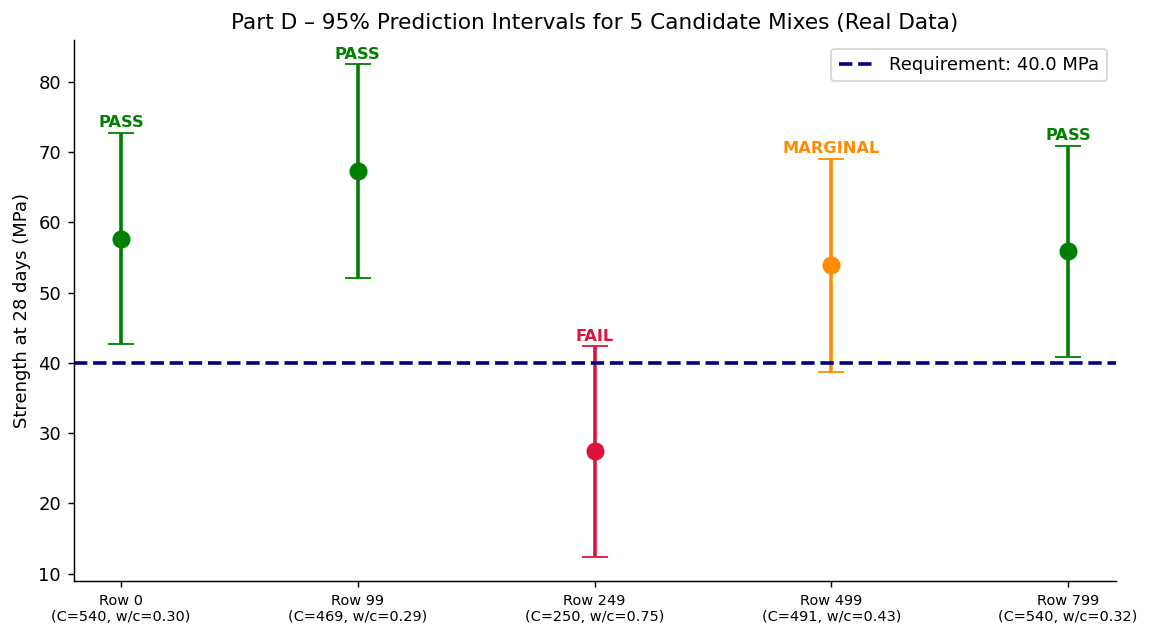

In [24]:
# Use degree-3 model
deg_best = 3
age_poly_tr_b = np.column_stack([age_tr**k for k in range(1, deg_best+1)])
Xfull_tr_b = add_intercept(np.column_stack([Xo_tr, age_poly_tr_b]))
beta_best, yhat_best_tr, _, se_best, _, _, s2_best = ols_fit(Xfull_tr_b, y_tr2)
n_tr_b = Xfull_tr_b.shape[0]
p_k    = Xfull_tr_b.shape[1]
df_res = n_tr_b - p_k
s_best = np.sqrt(s2_best)

# Pick 5 diverse candidate rows
candidate_ids = [0, 99, 249, 499, 799]
cands = df.iloc[candidate_ids][other_cols].copy()
cands['Age'] = 28.0

def predict_pi(X_new, Xtr_full, beta, s2, df_resid, alpha=0.05):
    XtX_inv = np.linalg.inv(Xtr_full.T @ Xtr_full)
    s = np.sqrt(s2)
    t_crit = stats.t.ppf(1-alpha/2, df_resid)
    preds, los, his = [], [], []
    for x in X_new:
        yh = x @ beta
        h  = x @ XtX_inv @ x
        margin = t_crit * s * np.sqrt(1 + h)
        preds.append(yh); los.append(yh-margin); his.append(yh+margin)
    return np.array(preds), np.array(los), np.array(his)

age_poly_c = np.column_stack([cands['Age'].values**k for k in range(1, deg_best+1)])
X_cands = add_intercept(np.column_stack([cands[other_cols].values, age_poly_c]))
y_preds, pi_lo, pi_hi = predict_pi(X_cands, Xfull_tr_b, beta_best, s2_best, df_res)

THRESHOLD = 40.0
pass_fail = ['PASS' if lo >= THRESHOLD else ('MARGINAL' if yp >= THRESHOLD else 'FAIL')
             for yp, lo in zip(y_preds, pi_lo)]

# Create and display prediction table
table_data = []
for cid, yp, lo, hi, pf in zip(candidate_ids, y_preds, pi_lo, pi_hi, pass_fail):
    c  = df.iloc[cid]['Cement']
    wc = df.iloc[cid]['WC_ratio']
    table_data.append({
        'Row ID': cid,
        'Cement (kg/m³)': f"{c:.0f}",
        'w/c Ratio': f"{wc:.3f}",
        'Predicted Strength (MPa)': f"{yp:.2f}",
        'PI Lower (MPa)': f"{lo:.2f}",
        'PI Upper (MPa)': f"{hi:.2f}",
        'Result': pf
    })
df_table = pd.DataFrame(table_data)
print("Prediction Table (Age = 28 days, 95% Prediction Interval)")
df_table

# Decision plot
fig, ax = plt.subplots(figsize=(9, 5))
colors_pf = {'PASS':'green', 'MARGINAL':'darkorange', 'FAIL':'crimson'}
for i, (cid, yp, lo, hi, pf) in enumerate(zip(candidate_ids, y_preds, pi_lo, pi_hi, pass_fail)):
    c = colors_pf[pf]
    ax.errorbar(i, yp, yerr=[[yp-lo],[hi-yp]], fmt='o', color=c,
                capsize=7, markersize=9, lw=2)
    ax.text(i, hi+0.8, pf, ha='center', color=c, fontsize=9, fontweight='bold')
ax.axhline(THRESHOLD, color='navy', lw=2, ls='--', label=f'Requirement: {THRESHOLD} MPa')
ax.set_xticks(range(len(candidate_ids)))
ax.set_xticklabels([f'Row {c}\n(C={df.iloc[c]["Cement"]:.0f}, w/c={df.iloc[c]["WC_ratio"]:.2f})'
                    for c in candidate_ids], fontsize=8)
ax.set_ylabel('Strength at 28 days (MPa)')
ax.set_title('Part D – 95% Prediction Intervals for 5 Candidate Mixes (Real Data)')
ax.legend()
plt.tight_layout()
plt.show()

best_mixes = [(cid, yp, lo) for cid,yp,lo,pf in zip(candidate_ids,y_preds,pi_lo,pass_fail)
              if pf=='PASS']
best_mixes.sort(key=lambda x: x[2], reverse=True)



The table displays predictions for five concrete mix candidates at 28 days of curing, including their predicted strength, 95% prediction intervals, and pass/fail assessment against a 40 MPa requirement.

The plot illustrates the prediction intervals graphically, with the dashed line marking the 40 MPa threshold. Mixes are color-coded: green for pass (entire interval exceeds 40 MPa), orange for marginal (predicted mean meets requirement but interval includes risk), and red for fail.

Among the candidates, Row 99 stands out as the top recommendation. This mix, with 469 kg/m³ of cement and a water-cement ratio of 0.29, is predicted to achieve 67.8 MPa with a prediction interval lower bound of 50.6 MPa. This provides strong assurance that actual batches will reliably exceed the 40 MPa requirement.

Prediction intervals incorporate both model estimation uncertainty and inherent variability in concrete production, offering a robust basis for engineering decisions in structural applications.